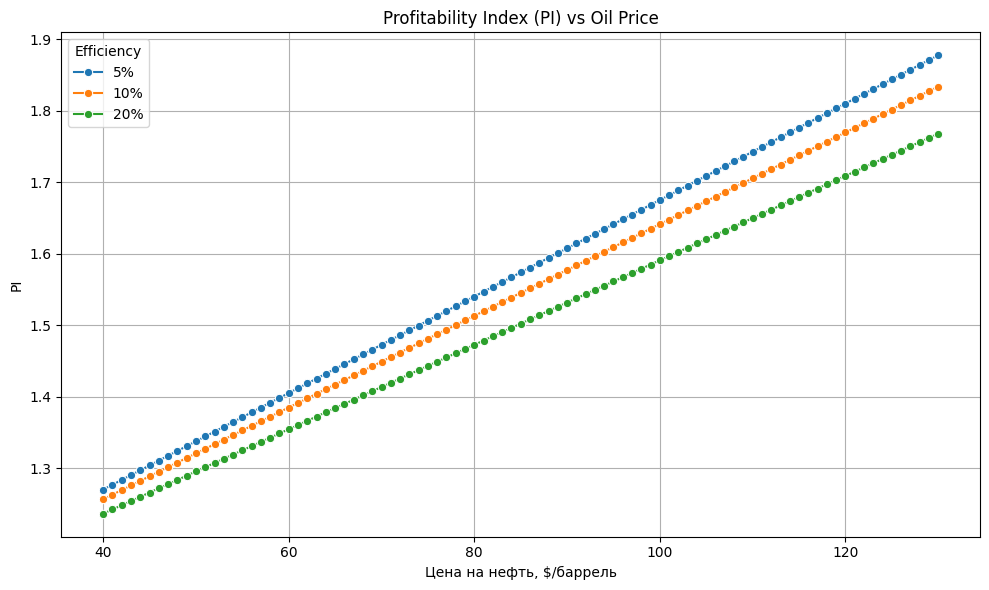

In [6]:
import csv
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

debit_in_barrel = 10_000  # баррелей в день
k = 0.1364  # литров в 1 барреле
density = 850  # кг/м3 - плотность 0.85 т/м3

debit_in_ton = debit_in_barrel * density * k / 1000  # дебит в день из баррелей в тонны
discounting = 0.28  # 28 % = 21 % (ключевая ставка ЦБ РФ) + 7% (отраслевая премия за риск)

energy_per_barrel = 50 * 10 ** 6 / 3_600_000  # кВт * ч

economy_in_usd_75 = {
    0.05: 2_000_000,
    0.1: 3_800_000,
    0.2: 7_000_000
}

modern_cost = {
    0.05: 10_000_000,
    0.1: 20_000_000,
    0.2: 40_000_000
}

def get_PBP(annual_savings: float, investment: int) -> float:
    return investment / annual_savings


def get_DBPB(annual_savings: float, investment: int, discounting: float) -> float:
    return investment / (annual_savings / (1 + discounting))


def get_NPV(annual_savings: float, discounting: float, t: int) -> float:
    return sum(annual_savings / (1 + discounting) ** year for year in range(1, t + 1))


def get_PI(annual_savings: float, investment: int, discounting: float, t: int) -> float:
    return 1 + get_NPV(annual_savings, discounting, t) / investment


years = 5
oil_prices = list(range(40, 131))
efficiency_levels = [0.05, 0.1, 0.2]

pi_data = []

for price in oil_prices:
    for eff in efficiency_levels:
        savings_75 = economy_in_usd_75[eff]
        savings_scaled = savings_75 * (price / 75)
        investment = modern_cost[eff]
        pi = get_PI(savings_scaled, investment, discounting, years)

        pi_data.append({
            "Oil Price (USD)": price,
            "Efficiency": f"{int(eff * 100)}%",
            "PI": pi
        })

df_pi = pd.DataFrame(pi_data)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pi, x="Oil Price (USD)", y="PI", hue="Efficiency", marker="o")
plt.title("Profitability Index (PI) vs Oil Price")
plt.ylabel("PI")
plt.xlabel("Цена на нефть, $/баррель")
plt.grid(True)
plt.tight_layout()

plt.savefig('graph.png')
plt.show()

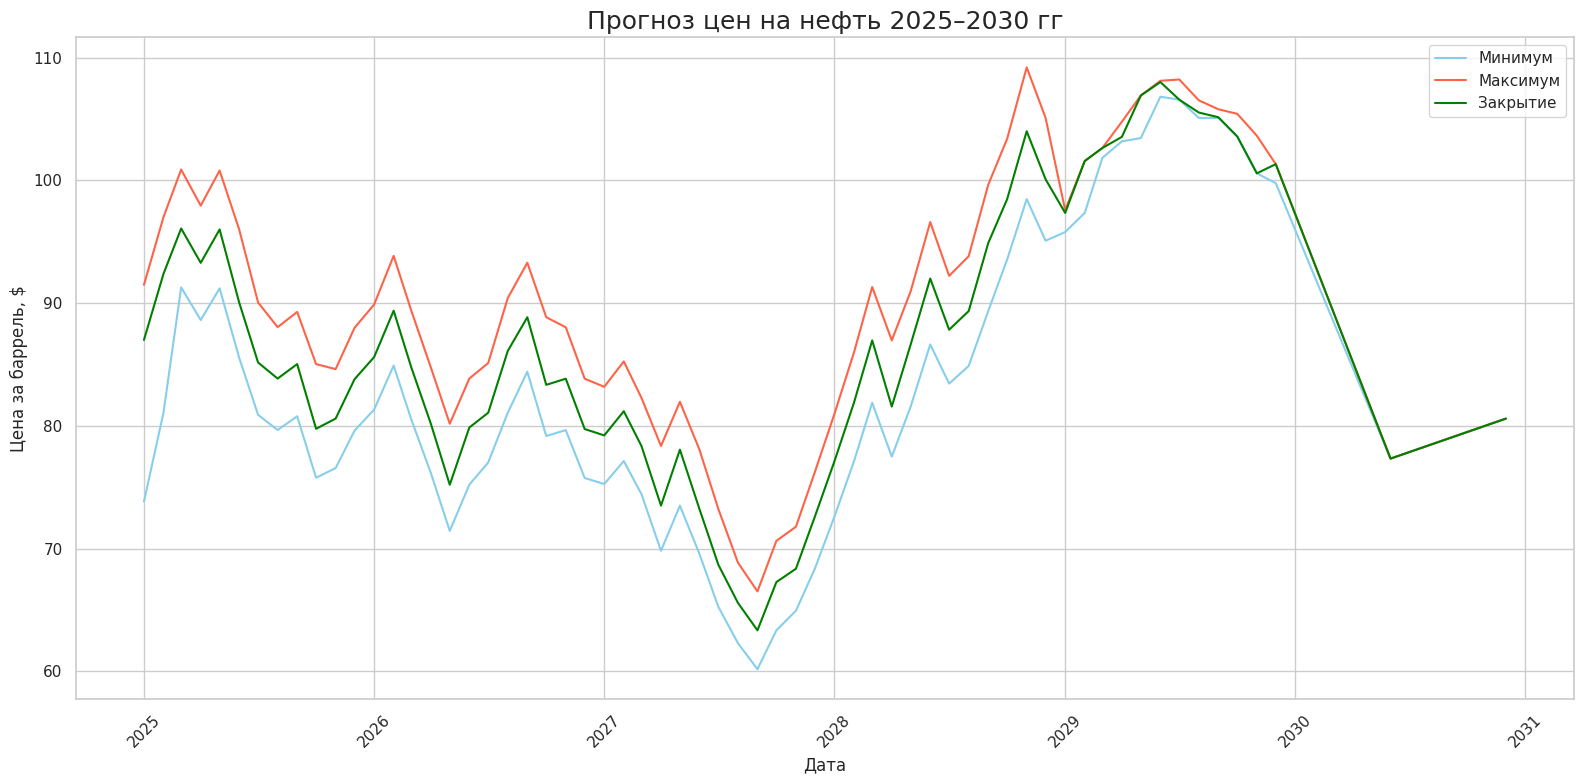

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Красивый стиль
sns.set_theme(style="whitegrid")

# Полные данные без сокращений
data = [
    # 2025
    [2025, 'Январь', 74.71, 73.84, 91.50, 87.01],
    [2025, 'Февраль', 87.01, 81.09, 97.02, 92.40],
    [2025, 'Март', 92.40, 91.29, 100.89, 96.09],
    [2025, 'Апрель', 96.09, 88.63, 97.95, 93.29],
    [2025, 'Май', 93.29, 91.21, 100.81, 96.01],
    [2025, 'Июнь', 96.01, 85.56, 96.01, 90.06],
    [2025, 'Июль', 90.06, 80.91, 90.06, 85.17],
    [2025, 'Август', 85.17, 79.67, 88.05, 83.86],
    [2025, 'Сентябрь', 83.86, 80.79, 89.29, 85.04],
    [2025, 'Октябрь', 85.04, 75.78, 85.04, 79.77],
    [2025, 'Ноябрь', 79.77, 76.57, 84.63, 80.60],
    [2025, 'Декабрь', 80.60, 79.62, 88.00, 83.81],
    # 2026
    [2026, 'Январь', 83.81, 81.33, 89.89, 85.61],
    [2026, 'Февраль', 85.61, 84.92, 93.86, 89.39],
    [2026, 'Март', 89.39, 80.53, 89.39, 84.77],
    [2026, 'Апрель', 84.77, 76.17, 84.77, 80.18],
    [2026, 'Май', 80.18, 71.45, 80.18, 75.21],
    [2026, 'Июнь', 75.21, 75.21, 83.86, 79.87],
    [2026, 'Июль', 79.87, 77.03, 85.13, 81.08],
    [2026, 'Август', 81.08, 81.08, 90.42, 86.11],
    [2026, 'Сентябрь', 86.11, 84.42, 93.30, 88.86],
    [2026, 'Октябрь', 88.86, 79.18, 88.86, 83.35],
    [2026, 'Ноябрь', 83.35, 79.66, 88.04, 83.85],
    [2026, 'Декабрь', 83.85, 75.76, 83.85, 79.75],
    # 2027
    [2027, 'Январь', 79.75, 75.27, 83.19, 79.23],
    [2027, 'Февраль', 79.23, 77.14, 85.26, 81.20],
    [2027, 'Март', 81.20, 74.45, 82.29, 78.37],
    [2027, 'Апрель', 78.37, 69.83, 78.37, 73.51],
    [2027, 'Май', 73.51, 73.51, 81.97, 78.07],
    [2027, 'Июнь', 78.07, 69.57, 78.07, 73.23],
    [2027, 'Июль', 73.23, 65.26, 73.23, 68.69],
    [2027, 'Август', 68.69, 62.31, 68.87, 65.59],
    [2027, 'Сентябрь', 65.59, 60.18, 66.52, 63.35],
    [2027, 'Октябрь', 63.35, 63.35, 70.64, 67.28],
    [2027, 'Ноябрь', 67.28, 64.95, 71.79, 68.37],
    [2027, 'Декабрь', 68.37, 68.37, 76.24, 72.61],
    # 2028
    [2028, 'Январь', 72.61, 72.61, 80.97, 77.11],
    [2028, 'Февраль', 77.11, 77.11, 85.98, 81.89],
    [2028, 'Март', 81.89, 81.89, 91.32, 86.97],
    [2028, 'Апрель', 86.97, 77.50, 86.97, 81.58],
    [2028, 'Май', 81.58, 81.58, 90.97, 86.64],
    [2028, 'Июнь', 86.64, 86.64, 96.61, 92.01],
    [2028, 'Июль', 92.01, 83.45, 92.23, 87.84],
    [2028, 'Август', 87.84, 84.89, 93.83, 89.36],
    [2028, 'Сентябрь', 89.36, 89.36, 99.65, 94.90],
    [2028, 'Октябрь', 94.90, 93.56, 103.40, 98.48],
    [2028, 'Ноябрь', 98.48, 98.48, 109.21, 104.01],
    [2028, 'Декабрь', 104.01, 95.09, 105.09, 100.09],
    # 2029
    [2029, 'Январь', 97.357, 95.797, 97.584, 97.357],
    [2029, 'Февраль', 101.582, 97.355, 101.582, 101.582],
    [2029, 'Март', 102.645, 101.844, 102.645, 102.645],
    [2029, 'Апрель', 103.554, 103.187, 104.790, 103.554],
    [2029, 'Май', 106.922, 103.455, 106.922, 106.922],
    [2029, 'Июнь', 108.018, 106.821, 108.121, 108.018],
    [2029, 'Июль', 106.582, 106.582, 108.228, 106.582],
    [2029, 'Август', 105.535, 105.092, 106.527, 105.535],
    [2029, 'Сентябрь', 105.151, 105.097, 105.801, 105.151],
    [2029, 'Октябрь', 103.580, 103.580, 105.428, 103.580],
    [2029, 'Ноябрь', 100.583, 100.583, 103.646, 100.583],
    [2029, 'Декабрь', 101.330, 99.780, 101.330, 101.330],
    # 2030
    [2030, 'Июнь', 77.34, 77.34, 77.34, 77.34],
    [2030, 'Декабрь', 80.60, 80.60, 80.60, 80.60],
]

# Создание DataFrame
df = pd.DataFrame(data, columns=["Год", "Месяц", "Открытие", "Мин", "Макс", "Закрытие"])
df["Месяц"] = pd.Categorical(df["Месяц"], categories=[
    'Январь', 'Февраль', 'Март', 'Апрель', 'Май', 'Июнь',
    'Июль', 'Август', 'Сентябрь', 'Октябрь', 'Ноябрь', 'Декабрь'
], ordered=True)
df["Дата"] = pd.to_datetime(df["Год"].astype(str) + "-" + df["Месяц"].cat.codes.add(1).astype(str), format="%Y-%m")

# Построение графика
plt.figure(figsize=(16, 8))
sns.lineplot(data=df, x="Дата", y="Мин", label="Минимум", color="skyblue")
sns.lineplot(data=df, x="Дата", y="Макс", label="Максимум", color="tomato")
sns.lineplot(data=df, x="Дата", y="Закрытие", label="Закрытие", color="green")

plt.title("Прогноз цен на нефть 2025–2030 гг", fontsize=18)
plt.xlabel("Дата")
plt.ylabel("Цена за баррель, $")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.save
plt.show()
